# Requirements
#### **(Preferred: make each one of requirment in md cell then your answer te be more organized.)**
#### **(Note: You can use another image, but upload it so I can see the original one.)**
### 1. Load the Image

* Read the image.
* Display the original image.
* Print its width, height, and number of channels.

---

### 2. Image Preprocessing

Improve the image quality by applying suitable preprocessing techniques such as:

* Grayscale conversion
* Noise reduction
* Image sharpening (if needed)
* Contrast enhancement

---

### 3. Edge Detection

Detect the major edges in the image using an appropriate method.

Display the detected edges.

---

### 4. Detect the Document

Locate the document inside the image.

Draw its contour on the original image.

---

### 5. Perspective Correction

Apply a Perspective Transform to obtain a top-down scanned version of the document.

---

### 6. Produce a Scanned Document

Generate a clean black-and-white scanned image using suitable thresholding techniques.

---

### 7. Contour Analysis

Extract all significant contours from the processed image.

For each contour:

* Draw its bounding rectangle.
* Display its area.
* Ignore very small contours.

---

### 8. Shape Detection

Detect and classify simple geometric shapes whenever possible.

Examples:

* Rectangle
* Square
* Circle
* Triangle

---

### 9. Histogram Analysis

Display the image histogram.

Briefly explain what the histogram indicates about the image.

---

### 10. Color Space Analysis

Convert the image into at least **two different color spaces**.

Explain why each color space could be useful.

---

### 11. Image Comparison

Compare:

* Original image
* Final processed image

Use:

* MSE
* SSIM

Comment on the obtained values.

---

### 12. Final Visualization

Create one final image showing:

* Document boundary
* Corner points
* Bounding boxes
* Any detected shapes
* Labels

---

# Bonus (Optional)

Implement any **three** of the following:

* Automatic image rotation.
* Automatic brightness correction.
* Shadow removal.
* Line detection using Hough Transform.
* Corner detection.
* Template Matching.
* Dominant color extraction using K-Means.
* Object counting.
* OCR-ready preprocessing.

## Imports 

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 1. Load the Image

In [2]:
def show_image(title="",image= None):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

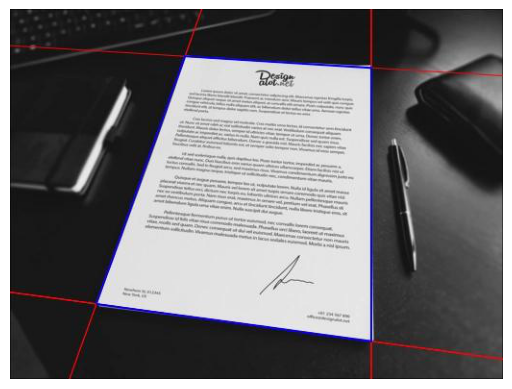

In [3]:
img = cv2.imread('Task.jpeg')
show_image(image=img)

In [4]:
h, w, c = img.shape
print(f"Height = {h}")
print(f"Width = {w}")
print(f"Channels = {c}")

Height = 385
Width = 513
Channels = 3


### 2. Image Preprocessing

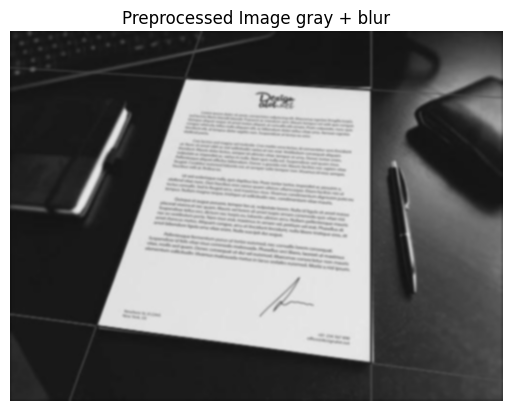

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5),0)
show_image("Preprocessed Image gray + blur", blur)

### 3. Edge Detection

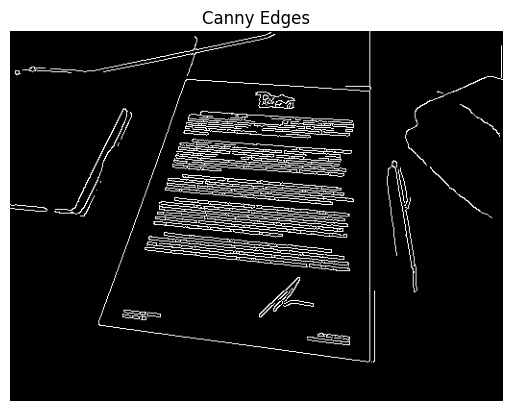

In [6]:
edges = cv2.Canny(blur, 50, 150)

show_image('Canny Edges', edges)

### 4. Detect the Document

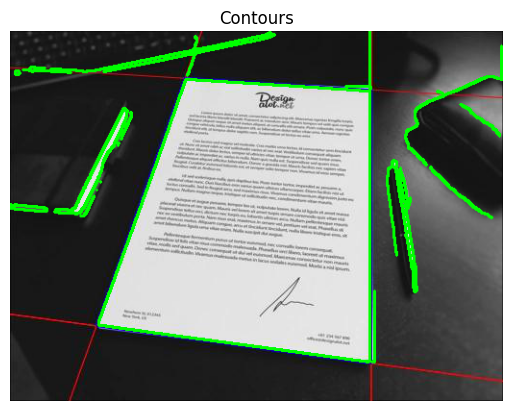

Number of Contours found = 22


In [7]:
contours, hierarchies = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_img = img.copy()
cv2.drawContours(contour_img, contours, -1, (0,255,0), thickness = 2)
show_image('Contours', contour_img)
print("Number of Contours found = " + str(len(contours)))

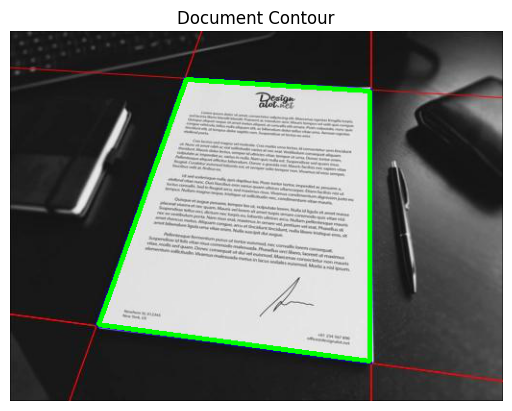

In [8]:
contours = sorted(contours, key=cv2.contourArea, reverse=True)

doc_contour = None
for c in contours:
    acc = 0.03 * cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, acc, True)
    if len(approx) == 4: 
        doc_contour = approx
        break

contour_img = img.copy()
cv2.drawContours(contour_img,[doc_contour], -1, (0,255,0), thickness = 3)
show_image('Document Contour', contour_img)

### 5. Perspective Correction

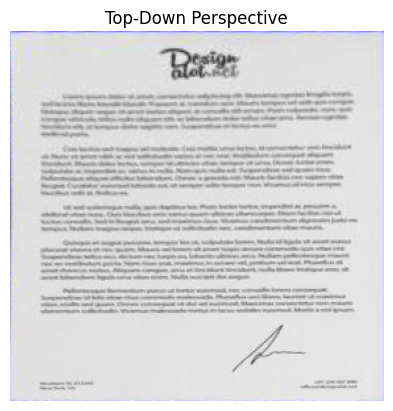

In [9]:
pts = doc_contour.reshape(4, 2)
rect = np.zeros((4, 2), dtype="float32")
s = pts.sum(axis=1)
rect[0] = pts[np.argmin(s)] #top-l
rect[2] = pts[np.argmax(s)] #bot-r
diff = np.diff(pts, axis=1)
rect[1] = pts[np.argmin(diff)] #top-r
rect[3] = pts[np.argmax(diff)] #bot-l

(tl, tr, br, bl) = rect
width = max(int(np.linalg.norm(br - bl)), int(np.linalg.norm(tr - tl)))
height = max(int(np.linalg.norm(tr - br)), int(np.linalg.norm(tl - bl)))

dst = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], dtype="float32")


m = cv2.getPerspectiveTransform(rect, dst)
warped = cv2.warpPerspective(img, m, (width, height))

show_image("Top-Down Perspective", warped)

### 6. Produce a Scanned Document

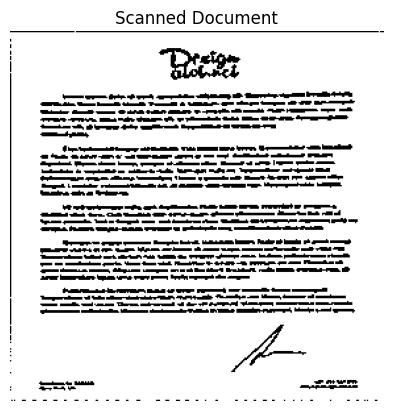

In [10]:
warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
scanned = cv2.adaptiveThreshold(
    warped_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    21, 10
)

show_image("Scanned Document", cv2.cvtColor(scanned, cv2.COLOR_GRAY2BGR))


### 7-8. Contour Analysis & Shape Detection

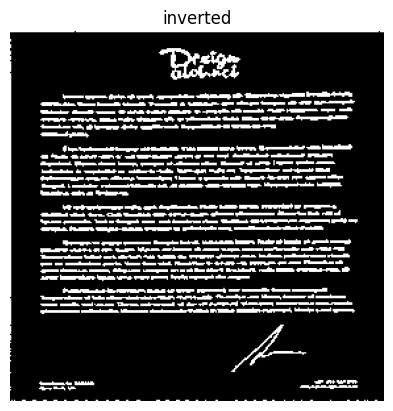

Raw contours found: 378
Kept after remove noise : 32


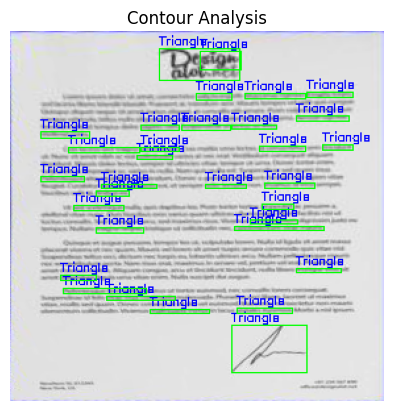

In [15]:
scan_inv = cv2.bitwise_not(scanned)
show_image("inverted", scan_inv)

cnts, _ = cv2.findContours(scan_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Raw contours found: {len(cnts)}")

MIN_AREA = 40 #ignore noise

analysis_img = warped.copy()
kept = 0
for c in cnts:
    area = cv2.contourArea(c)
    if area < MIN_AREA:
        continue

    acc = 0.04* cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, acc, True)
    v = len(approx)
    
    if v == 3: s = "Triangle"
    elif v == 4: s = "Rectangle"
    elif v > 8: s = "Circle"
    else: v = "Unknown"
        
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(analysis_img, (x, y), (x + w, y + h), (0, 255, 0), 1)    
    cv2.putText(analysis_img, s,(x, max(y - 3, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 0, 0), 1)
    kept += 1

print(f"Kept after remove noise : {kept}")
show_image("Contour Analysis", analysis_img)


### 9. Histogram Analysis

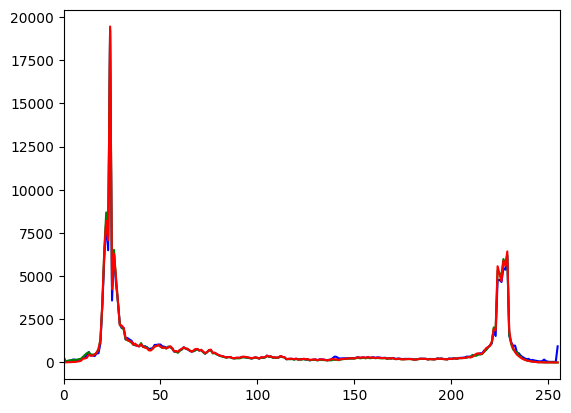

In [19]:
colors = ('b', 'g', 'r')
for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.xlim([0, 256])
plt.show()

the histogram tells us that  the distribution is skewed toward the dark end  it also explains why edge detection so reliably locks onto the page boundary

### 10. Color Space Analysis

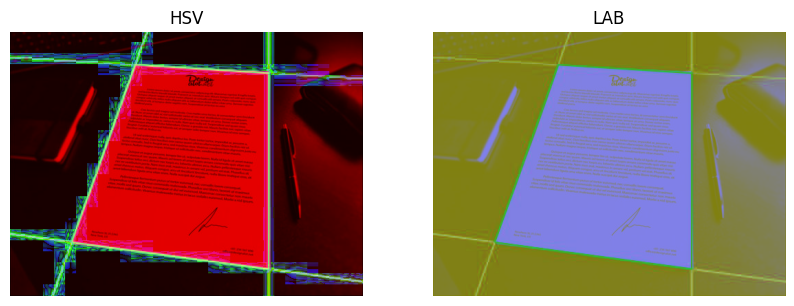

In [21]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(hsv, cv2.COLOR_BGR2RGB))
axes[0].set_title("HSV")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(lab, cv2.COLOR_BGR2RGB))
axes[1].set_title("LAB")
axes[1].axis('off')
plt.show()

**HSV** very useful for isolating the red guide lines in this image by color regardless of lighting changes

**LAB** give more consistent results under uneven lighting or colored shadows as it separates perceptual lightness (L) from color information (A, B). 

### 11. Image Comparison

In [26]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

resized_scan = cv2.resize(scanned, (img.shape[1], img.shape[0]))

mse_val = mse(gray, resized_scan)
ssim_val = ssim(gray, resized_scan)

print(f"MSE = {mse_val:.2f}")
print(f"SSIM = {ssim_val:.4f}")

MSE = 29790.77
SSIM = 0.1444


As both the MSE (large) and SSIM (close to 0) indicate the two images are very different pixel-for-pixel even they same content 

### 12. Final Visualization

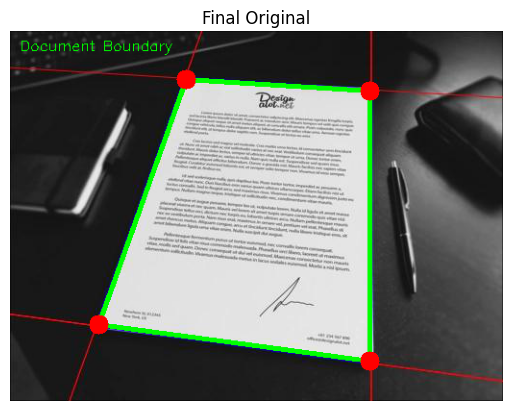

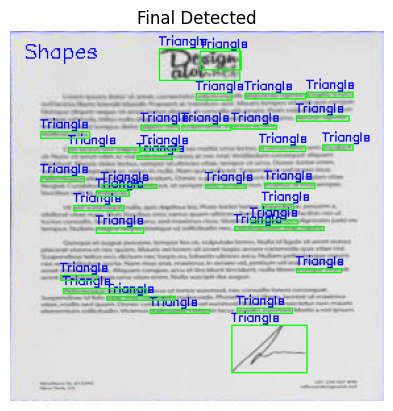

In [32]:
final_original = img.copy()
cv2.drawContours(final_original, [doc_contour], -1, (0, 255, 0), 3) 

for point in doc_contour:
    x, y = point[0]
    cv2.circle(final_original, (x, y), 10, (0, 0, 255), -1)  
    
cv2.putText(final_original, "Document Boundary", (10, 20),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

show_image("Final Original", final_original)

final_detected = analysis_img.copy()
cv2.putText(final_detected, "Shapes", (10, 20),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
show_image("Final Detected", final_detected)
